In [2]:
# from numba import cuda
import paicos as pa
import numpy as np
import cupy as cp
import turbocluster as tc
import math
from numba import cuda
import nvtx
import cmasher as cmr
import scipy.signal
# import finufft
%matplotlib widget

pa.settings.strict_units = False

# A snapshot object
# snap = pa.Snapshot(pa.data_dir, 247)
snap = pa.Snapshot('/llust21/cosmo-plasm/zoom-simulations-arepo2/halo_0003/tng/zoom12/output', 305, 
                   basename='snapshot')
# snap = pa.Snapshot('/lustre/astro/berlok/zoom-simulations-new-ics/halo_0003/tng/zoom12_ics_v1/output', 247)
center = snap.Cat.Group['GroupPos'][0]
widths = np.array([1000., 1000., 1000.], dtype=float)

# m_filter = 1000*snap.mass
# filter_length = (np.cbrt(3*m_filter/(4*np.pi*snap['0_Density']))).arepo
# filter_length = 2*snap['0_Diameters']


In [3]:
arepo_length = snap['0_Diameters'].uq
filter_length = 4*25*np.ones(snap['0_Diameters'].shape)*arepo_length
filter_type = 'gaussian'
nGrid = 256

Attempting to get derived variable: 0_Diameters...
	So we need the variable: 0_Volume...	[DONE]



In [4]:
# sf = tc.SmoothingFilter(snap, center, widths, npix=256, orientation=None, 
#                         search_radius=5.*filter_length.value)

In [5]:
# smoothVar, turbVar = tc.extract_turbulent_scalar(snap, sf, '0_Density', filter_length=filter_length, 
#                                               weight='0_Volume', filter_type=filter_type, iterative=False)

# relativeTurbVar = np.zeros(snap['0_Density'].shape)
# relativeTurbVar[sf.index] = turbVar[sf.index].value/snap['0_Density'][sf.index].value

In [6]:
# relativeTurbVar

In [7]:
# from paicos import units as pu
# from astropy import units as u
# snap['0_RelTurbDens']= pa.units.PaicosQuantity(relativeTurbVar, h=snap.h, a=snap.a, 
#                                           unit=u.dimensionless_unscaled, comoving_sim=True)

In [8]:
depo = tc.DepositCartesianGrid(snap, center, widths, npoints=nGrid, threadsperblock=256, 
                               regionType='cartesian', kernel_type="PCS")

In [9]:
density_cartesian = depo.deposit_variable('0_Density', weight='0_Volume')

In [10]:
# density_cartesian

In [11]:
# turb_rel_density_cartesian = depo.deposit_variable('0_RelTurbDens', weight='0_Volume')

In [12]:
# turb_rel_density_cartesian

In [13]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize

widths_slicer = widths.copy()
widths_slicer[2] = 0.
slicer = pa.Slicer(snap, center, widths_slicer, 'z', npix=1024)
extent = slicer.centered_extent.to('Mpc')

In [14]:
# dens_voro = slicer.slice_variable('0_RelTurbDens')
# """ 
# I am not sure why here I need to transpose to make sure
# the alignment is the same as the slice
# """ 
# dens_cart = turb_rel_density_cartesian[:,:,int(depo.npixs[2]//2)-1].T
# # dens_bulk = slicer.slice_variable(smoothVar)
# # dens_turb = slicer.slice_variable(relativeTurbVar)
# # delta_density_rel = (dens_voro - dens_cart)

# dens_voro = dens_voro.to_physical
# dens_cart = dens_cart.to_physical
# # dens_turb = dens_turb.to_physical.cgs

# vmin = -np.max(dens_voro.value)
# # print(vmin)
# vmax = np.max(dens_voro.value)
# # print(vmax)
# # norm = LogNorm(vmin=vmin,vmax=vmax)
# norm = Normalize(vmin=vmin,vmax=vmax)

# # vmin = -0.8*delta_density_rel.max()
# # vmax = 0.8*delta_density_rel.max()
# # print(vmin)
# # norm1 = Normalize(vmin=vmin,vmax=vmax)
# # norm = norm1
# cmap = cmr.fusion

# fig, axes = plt.subplots(1,2, figsize=(8,6),sharex=True, sharey=True)

# im1 = axes[0].imshow(
#     dens_voro.value, origin='lower', norm=norm, cmap=cmap, extent=extent.value)

# im2 = axes[1].imshow(
#     dens_cart.value, origin='lower', norm=norm, cmap=cmap, extent=extent.value)

# # im3 = axes[2].imshow(
# #     delta_density_rel, origin='lower', norm=norm1, cmap=cmap, extent=extent.value)

# axes[0].set_title('Voronoi slice')
# axes[1].set_title('Cartesian deposition')
# # axes[2].set_title('Relative difference')


# for i in range(2):
#     axes[i].set_xlabel(extent.label('x'))

# axes[0].set_ylabel(extent.label('y'))



# cbar = fig.colorbar(im1, orientation='horizontal')
# cbar.set_label(dens_voro.label('\\delta \\rho / \\rho'))

# cbar = fig.colorbar(im2, orientation='horizontal')
# cbar.set_label(dens_cart.label('\\delta \\rho / \\rho'))

# # cbar = fig.colorbar(im3, orientation='horizontal')
# # cbar.set_label(delta_density_rel.label('\\Delta \\delta \\rho / \\rho'))


# fig.subplots_adjust(top=0.85,
# bottom=0.1,
# left=0.10,
# right=0.90,
# hspace=0.0,
# wspace=0.05)

# fig.suptitle('Turbulent density field (voronoi and cartesian)',y=0.95)
# # plt.savefig(f'Halo{halo}_density_center_non_starforming.pdf')
# # plt.close()

In [15]:
@cuda.jit(lineinfo=True)
def _gpu_power_spectrum1d(vhat, kvec, Ngrid, Ncomplex, powerspectr):
    # vhat has shape: 
    # (Nx,Ny,Nz) if complex transform, or
    # (Nx,Ny,Nz//2+1) if real transform
    # Ngrid is a tuple with the dimension
    # of the real grid (Nx, Ny, Nz)
    # Ncomplex is a tuple with the dimension
    # of the complex grid:
    # (Nx, Ny, Nz) if C2C
    # (Nx, Ny, Nz//2+1) if R2C
    
    Nx, Ny, Nz = Ngrid
    ntotal = Nx*Ny*Nz
    ncomplex_kx, ncomplex_ky, ncomplex_kz = Ncomplex
    ntotal_complex = ncomplex_kx * ncomplex_ky * ncomplex_kz
    
    ip = cuda.grid(1)

    if (ip < ntotal_complex):
        k = ip % ncomplex_kz
        ip_tmp = int((ip - k)/ncomplex_kz)
        j = ip_tmp % ncomplex_ky
        i = ip_tmp // ncomplex_ky
    
        # kx =  ( i +  float(Nx) / 2.0) %  Nx  - Nx / 2 
        # ky =  ( j +  float(Ny) / 2.0) %  Ny  - Ny / 2 
        # if (ncomplex_kz == Nz//2 + 1):
        #     kz = k
        # else:
        #     kz =  ( k +  float(Nz) / 2.0) %  Nz  - Nz / 2 

        # # this is to take into account that 
        # # the widths of the region can be different
        # # but the Ny,Nz are chosen such that
        # # the spacing is uniform in all 3 directions
        # ky *= Nx / Ny
        # kz *= Nx / Nz

        power_at_freq = (vhat[i,j,k] * vhat[i,j,k].conjugate() ).real
        
        freq = int(kvec[i,j,k] + 0.5)
        # # if we are doing a real fft
        # # we need to double to take into account
        # # energy contained in the negative KZ midplane
        if (k > 0 and (ncomplex_kz - 1) % (Nz//2) == 0): 
        # if (k > 0):
            power_at_freq *= 2.0
    
        # powerspectr[0,0,0] = i
        # cuda.atomic.add(powerspectr, (freq), 
        #                 power_at_freq / ((Nx*Ny*Nz)**2))
        cuda.atomic.add(powerspectr, (freq), 
                        power_at_freq / (ntotal**2))

@cuda.jit(lineinfo=True)
def _gpu_power_spectrum1d_finufft(vhat, kvec, Ngrid, Ncomplex, powerspectr, M):
    # vhat has shape: 
    # (Nx,Ny,Nz) if complex transform, or
    # (Nx,Ny,Nz//2+1) if real transform
    # Ngrid is a tuple with the dimension
    # of the real grid (Nx, Ny, Nz)
    # Ncomplex is a tuple with the dimension
    # of the complex grid:
    # (Nx, Ny, Nz) if C2C
    # (Nx, Ny, Nz//2+1) if R2C
    # M is the original length of the sampling points in finufft
    
    Nx, Ny, Nz = Ngrid
    ntotal = Nx*Ny*Nz
    ncomplex_kx, ncomplex_ky, ncomplex_kz = Ncomplex
    ntotal_complex = ncomplex_kx * ncomplex_ky * ncomplex_kz
    
    ip = cuda.grid(1)

    if (ip < ntotal_complex):
        k = ip % ncomplex_kz
        ip_tmp = int((ip - k)/ncomplex_kz)
        j = ip_tmp % ncomplex_ky
        i = ip_tmp // ncomplex_ky
    
        # kx =  ( i +  float(Nx) / 2.0) %  Nx  - Nx / 2 
        # ky =  ( j +  float(Ny) / 2.0) %  Ny  - Ny / 2 
        # if (ncomplex_kz == Nz//2 + 1):
        #     kz = k
        # else:
        #     kz =  ( k +  float(Nz) / 2.0) %  Nz  - Nz / 2 

        # # this is to take into account that 
        # # the widths of the region can be different
        # # but the Ny,Nz are chosen such that
        # # the spacing is uniform in all 3 directions
        # ky *= Nx / Ny
        # kz *= Nx / Nz

        power_at_freq = (vhat[i,j,k] * vhat[i,j,k].conjugate() ).real
        
        freq = int(kvec[i,j,k] + 0.5)
        # # if we are doing a real fft
        # # we need to double to take into account
        # # energy contained in the negative KZ midplane
        if (k > 0 and (ncomplex_kz - 1) % (Nz//2) == 0): 
        # if (k > 0):
            power_at_freq *= 2.0
    
        # powerspectr[0,0,0] = i
        # cuda.atomic.add(powerspectr, (freq), 
        #                 power_at_freq / ((Nx*Ny*Nz)**2))
        cuda.atomic.add(powerspectr, (freq), 
                        power_at_freq / (M**2))
        
def power_spectrum1d_gpu(KX, KY, KZ, vhat, Ngrid, Lx, finufft=False, M=-1):
    # vhat and KX, KY, KZ have the same shape: 
    # (Nx,Ny,Nz) if complex transform, or
    # (Nx,Ny,Nz//2+1) if real transform
    # Ngrid is a tuple with the dimension
    # of the real grid (Nx, Ny, Nz)
    Nx, Ny, Nz = Ngrid
    Ntotalcomplex = vhat.shape[0]*vhat.shape[1]*vhat.shape[2]

    if (finufft and M==-1):
        raise RuntimeError('The length of the original signal \
        has to be set')

    kvec = np.sqrt(KX**2 + KY**2 + KZ**2)

    kxmax = Nx/2
    kymax = kxmax
    kzmax = kxmax

    kmax = int(np.sqrt(kxmax**2 + kymax**2 + kzmax**2) + 0.5)
    kmin = 0
    k1d = np.arange(kmin, kmax+1)

    d_vhat = cp.array(vhat)
    d_kvec = cp.array(kvec)
    d_powerspectr = cp.zeros(k1d.shape)
    threadsperblock = 256
    blocks_1d = (Ntotalcomplex + (threadsperblock - 1)) // threadsperblock

    if not finufft:
        _gpu_power_spectrum1d[blocks_1d, threadsperblock](d_vhat, d_kvec, (Nx, Ny, Nz), 
                                                      (vhat.shape[0], vhat.shape[1], vhat.shape[2]), 
                                                      d_powerspectr)
    else:
        _gpu_power_spectrum1d_finufft[blocks_1d, threadsperblock](d_vhat, d_kvec, (Nx, Ny, Nz), 
                                                      (vhat.shape[0], vhat.shape[1], vhat.shape[2]), 
                                                      d_powerspectr, M)
    
    return cp.asnumpy(d_powerspectr), k1d*(2.0*np.pi/Lx)

In [16]:
# @cuda.jit(lineinfo=True)
# def _gpu_power_spectrum1d_finufft(vhat, kvec, Ngrid, Ncomplex, powerspectr):
#     # vhat and kvec have shape: 
#     # (Nx*Ny*(Nz//2+1),) 
#     # Ngrid is a tuple with the dimension
#     # of the real grid (Nx, Ny, Nz)
#     # Ncomplex is a tuple with the dimension
#     # of the complex grid:
#     # (Nx, Ny, Nz//2+1)
#     # we assume that the wavenumbers have been generated
#     # with meshgrid
    
#     Nx, Ny, Nz = Ngrid
#     ntotal = Nx*Ny*Nz
#     ncomplex_kx, ncomplex_ky, ncomplex_kz = Ncomplex
#     ntotal_complex = ncomplex_kx * ncomplex_ky * ncomplex_kz
    
#     ip = cuda.grid(1)

#     if (ip < ntotal_complex):
#         k = ip % ncomplex_kz
#         # ip_tmp = int((ip - k)/ncomplex_kz)
#         # j = ip_tmp % ncomplex_ky
#         # i = ip_tmp // ncomplex_ky
    

#         power_at_freq = (vhat[ip] * vhat[ip].conjugate() ).real
        
#         freq = int(kvec[ip] + 0.5)
#         # # if we are doing a real fft
#         # # we need to double to take into account
#         # # energy contained in the negative KZ midplane
#         # if (k > 0 and ncomplex_kz == Nz//2 + 1):
#         if (k > 0):
#             power_at_freq *= 2.0
    
#         # powerspectr[0,0,0] = i
#         # cuda.atomic.add(powerspectr, (freq), 
#         #                 power_at_freq / ((Nx*Ny*Nz)**2))
#         cuda.atomic.add(powerspectr, (freq), 
#                         power_at_freq / (ntotal**2))

# def power_spectrum1d_gpu_finufft(KX, KY, KZ, vhat, Ngrid, Lx):
#     # vhat has shape: 
#     # (Nx*Ny*(Nz//2+1))
#     # and KX, KY, KZ have the same shape: 
#     # (Nx,Ny,(Nz//2+1))
#     # Ngrid is a tuple with the dimension
#     # of the real grid (Nx, Ny, Nz)
#     Nx, Ny, Nz = Ngrid
#     Ntotalcomplex = vhat.shape[0]
    
#     kvec = np.sqrt(KX**2 + KY**2 + KZ**2).flatten()

#     kxmax = Nx/2
#     kymax = kxmax
#     kzmax = kxmax

#     kmax = int(np.sqrt(kxmax**2 + kymax**2 + kzmax**2) + 0.5)
#     kmin = 0
#     k1d = np.arange(kmin, kmax+1)

#     d_vhat = cp.array(vhat)
#     d_kvec = cp.array(kvec)
#     d_powerspectr = cp.zeros(k1d.shape)
#     threadsperblock = 256
#     blocks_1d = (Ntotalcomplex + (threadsperblock - 1)) // threadsperblock

#     _gpu_power_spectrum1d_finufft[blocks_1d, threadsperblock](d_vhat, d_kvec, (Nx, Ny, Nz), 
#                                                       (KX.shape[0], KX.shape[1], KX.shape[2]), 
#                                                       d_powerspectr)
    
#     return cp.asnumpy(d_powerspectr), k1d*(2.0*np.pi/Lx)

In [17]:
# def power_spectrum_numpyfft1d(KX, KY, KZ, vhat, Ns, Lx):
#     # vhat and KX, KY, KZ have the same shape: 
#     # (Nx,Ny,Nz) if complex transform, or
#     # (Nx,Ny,Nz//2+1) if real transform
#     # Ns is a tuple with the dimension
#     # of the real grid (Nx, Ny, Nz)
#     Nx, Ny, Nz = Ns
    
#     kvec = np.sqrt(KX**2 + KY**2 + KZ**2)
    
#     kmax = int(np.sqrt(kxmax**2 + kymax**2 + kzmax**2) + 0.5)
#     kmin = 0
#     k1d = np.arange(kmin, kmax+1)
#     powerspectr = np.zeros(k1d.shape)
    
#     for i in range(len(powerspectr)):
#         indicesUpperMidplane = np.argwhere(((kvec+0.5).astype('int')==k1d[i])*(KZ>0.0))
#         if (indicesUpperMidplane.size != 0):
#             powerspectr[i] = np.sum((vhat[indicesUpperMidplane[:,0],indicesUpperMidplane[:,1],indicesUpperMidplane[:,2]] \
#                                      *np.conj(vhat[indicesUpperMidplane[:,0],indicesUpperMidplane[:,1],indicesUpperMidplane[:,2]])).real) \
#                                     /((Nx*Ny*Nz)**2)
#             if (vhat.shape[-1] == Nz//2+1): 
#                 # we are doing a real fft
#                 # therefore we need to double to take into account
#                 # energy contained in the negative KZ midplane
#                 powerspectr[i] *= 2.0
#         indicesLowerMidplane = np.argwhere(((kvec+0.5).astype('int')==k1d[i])*(KZ<=0.0))
#         if (indicesLowerMidplane.size != 0):
#             powerspectr[i] += np.sum((vhat[indicesLowerMidplane[:,0],indicesLowerMidplane[:,1],indicesLowerMidplane[:,2]] \
#                                      *np.conj(vhat[indicesLowerMidplane[:,0],indicesLowerMidplane[:,1],indicesLowerMidplane[:,2]])).real) \
#                                     /((Nx*Ny*Nz)**2)
            
#     return powerspectr, k1d*(2.0*np.pi/Lx)

In [18]:
def _nd_window(data, filter_function):
    """
    https://stackoverflow.com/questions/27345861/extending-1d-function-across-3-dimensions-for-data-windowing
    Performs an in-place windowing on N-dimensional spatial-domain data.
    This is done to mitigate boundary effects in the FFT.

    Parameters
    ----------
    data : ndarray
           Input data to be windowed, modified in place.
    filter_function : 1D window generation function
           Function should accept one argument: the window length.
           Example: scipy.signal.windows.hann
    """
    windowed_data = data.value.copy()
    ndim_window = np.ones(data.shape)
    for axis, axis_size in enumerate(data.shape):
        # set up shape for numpy broadcasting
        filter_shape = [1, ] * data.ndim
        filter_shape[axis] = axis_size
        window = filter_function(axis_size).reshape(filter_shape)
        # scale the window intensities to maintain image intensity
        # np.power(window, (1.0/data.ndim), out=window)
        # window = window**(1.0/data.ndim)
        windowed_data *= window
        ndim_window *= window
    
    # norm_coeff = np.sqrt(np.sum(np.square(np.abs(ndim_window))))
    return windowed_data * data.unit_quantity, ndim_window

In [19]:
# this is the relative *turbulent* density fluctuation

Nx, Ny, Nz = depo.npoints.tolist()

# here d is the same for all because the 
# cartesian grid is created such that each 
# cell has Delta x = Delta y = Delta x
kx = np.fft.fftfreq(Nx, d=1.0/Nx)
ky = np.fft.fftfreq(Ny, d=1.0/Nx)
kz = np.fft.rfftfreq(Nz, d=1.0/Nx)

# By multiplying kx, ky, kz by (2.0 pi / L_x)
# we get physical wavenumbers (1/length)
Lx = depo.widths[0]

KX, KY, KZ = np.meshgrid(kx, ky, kz, indexing='ij')
hat_den = np.fft.rfftn(density_cartesian)
powerspectr, k1d = power_spectrum1d_gpu(KX, KY, KZ, hat_den, (Nx,Ny,Nz), Lx)

/home/lperrone/miniforge3/envs/paicos-conda/lib/python3.11/site-packages/numba/core/lowering.py:112: NumbaDebugInfoWarning: Could not find source for function: <function _gpu_power_spectrum1d at 0x7efc18170860>. Debug line information may be inaccurate.
  warnings.warn(NumbaDebugInfoWarning(msg))


In [20]:
# this is the density
# but windowed by the hann window

density_cartesian_hann, ndim_window = _nd_window(density_cartesian, 
                                             scipy.signal.windows.hann)

# normalization_window2 = np.sum(np.square(np.abs(window)))

hat_den_hann = np.fft.rfftn(density_cartesian_hann)
powerspectr_hann, k1d = power_spectrum1d_gpu(KX, KY, KZ, hat_den_hann, (Nx,Ny,Nz), Lx)
# powerspectr_hann /= np.square(np.sum(ndim_window)/(Nx*Ny*Nz))
powerspectr_hann /= np.sum(np.square(ndim_window))/(Nx*Ny*Nz)

# powerspectr_hann, k1d = power_spectrum1d_gpu(KX, KY, KZ, 
#                                              hat_turb_rel_den_hann, 
#                                              (Nx,Ny,Nz), Lx)

In [21]:
np.sum(np.square(ndim_window))

874408.4472656259

Text(0.5, 0.95, 'Density field (original and windowed)')

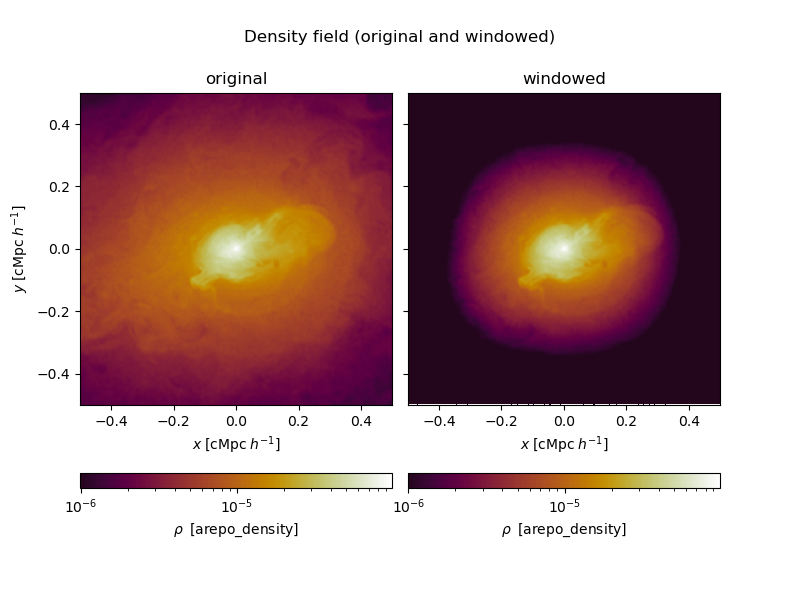

In [22]:
# dens_voro = slicer.slice_variable('0_RelTurbDens')
""" 
I am not sure why here I need to transpose to make sure
the alignment is the same as the slice
""" 
dens_cart = density_cartesian[:,:,int(depo.npoints[2]//2)-1].T
dens_cart_hann = density_cartesian_hann[:,:,int(depo.npoints[2]//2)-1].T
# dens_bulk = slicer.slice_variable(smoothVar)
# dens_turb = slicer.slice_variable(relativeTurbVar)
# delta_density_rel = (dens_voro - dens_cart)

dens_cart_hann = dens_cart_hann.to_physical
dens_cart = dens_cart.to_physical
# dens_turb = dens_turb.to_physical.cgs

vmax = np.max(dens_cart.value)
vmin = 1e-2*vmax
# print(vmin)

# print(vmax)
norm = LogNorm(vmin=vmin,vmax=vmax)
# norm = Normalize(vmin=vmin,vmax=vmax)

# vmin = -0.8*delta_density_rel.max()
# vmax = 0.8*delta_density_rel.max()
# print(vmin)
# norm1 = Normalize(vmin=vmin,vmax=vmax)
# norm = norm1
cmap = cmr.fall

fig, axes = plt.subplots(1,2, figsize=(8,6),sharex=True, sharey=True)

im1 = axes[0].imshow(
    dens_cart.value, origin='lower', norm=norm, cmap=cmap, extent=extent.value)

im2 = axes[1].imshow(
    dens_cart_hann.value, origin='lower', norm=norm, cmap=cmap, extent=extent.value)

# im3 = axes[2].imshow(
#     delta_density_rel, origin='lower', norm=norm1, cmap=cmap, extent=extent.value)

axes[0].set_title('original')
axes[1].set_title('windowed')
# axes[2].set_title('Relative difference')


for i in range(2):
    axes[i].set_xlabel(extent.label('x'))

axes[0].set_ylabel(extent.label('y'))



cbar = fig.colorbar(im1, orientation='horizontal')
cbar.set_label(dens_cart.label('\\rho'))

cbar = fig.colorbar(im2, orientation='horizontal')
cbar.set_label(dens_cart_hann.label('\\rho'))

# cbar = fig.colorbar(im3, orientation='horizontal')
# cbar.set_label(delta_density_rel.label('\\Delta \\delta \\rho / \\rho'))


fig.subplots_adjust(top=0.85,
bottom=0.1,
left=0.10,
right=0.90,
hspace=0.0,
wspace=0.05)

fig.suptitle('Density field (original and windowed)',y=0.95)
# plt.savefig(f'Halo{halo}_density_center_non_starforming.pdf')
# plt.close()

In [23]:
# this is the zero-padded relative *turbulent* density fluctuation
npads = 2
hat_den_zeropadded = np.fft.rfftn(density_cartesian, 
                                           s=(npads*Nx,npads*Ny,npads*Nz)) 

kx_pad = np.fft.fftfreq(npads*Nx, d=1.0/Nx)
ky_pad = np.fft.fftfreq(npads*Ny, d=1.0/Nx)
kz_pad = np.fft.rfftfreq(npads*Nz, d=1.0/Nx)

KX_pad, KY_pad, KZ_pad = np.meshgrid(kx_pad, ky_pad, kz_pad, indexing='ij')
powerspectr_padded, k1d_padded = power_spectrum1d_gpu(KX_pad, KY_pad, KZ_pad,
                                                      hat_den_zeropadded/np.sqrt(npads**3), 
                                                      (Nx,Ny,Nz), Lx)

In [24]:
# this is with finufft

# x = 2 * np.pi * (snap['0_Coordinates'][sf.indicesFirstPass][:, 0].value - ( center[0].value - widths[0]/2. )) / widths[0] - np.pi
# y = 2 * np.pi * (snap['0_Coordinates'][sf.indicesFirstPass][:, 1].value - ( center[1].value - widths[1]/2. )) / widths[1] - np.pi
# z = 2 * np.pi * (snap['0_Coordinates'][sf.indicesFirstPass][:, 2].value - ( center[2].value - widths[2]/2. )) / widths[2] - np.pi


# kkz = np.fft.fftfreq(Nz, d=1.0/Nx)
# KKX, KKY, KKZ = np.meshgrid(kx, ky, kkz, indexing='ij')


# # calculate the NUFFT
# # vhat_finufft = finufft.nufft3d3(x, y, z, relativeTurbVar[sf.index].astype('complex128'), 
# #                                 KX.flatten(), KY.flatten(), KZ.flatten())

# vhat_finufft = finufft.nufft3d1(x, y, z, relativeTurbVar[sf.indicesFirstPass].astype('complex128'), 
#                                 n_modes=(Nx,Ny,Nz))

# # this is to validate with grid points
# xx = 2.0*np.pi*np.arange(0,Nx)/Nx - np.pi
# yy = 2.0*np.pi*np.arange(0,Nx)/Nx - np.pi
# zz = 2.0*np.pi*np.arange(0,Nx)/Nx - np.pi

# X, Y, Z = np.meshgrid(xx, yy, zz, indexing='ij')

# # vhat_finufft = finufft.nufft3d1(X.flatten(), Y.flatten(), Z.flatten(), 
# #                                 turb_rel_density_cartesian.flatten().astype('complex128'), 
# #                                 n_modes=(Nx,Ny,Nz))

# vhat_finufft = np.fft.ifftshift(vhat_finufft)

# good for type 1 finufft
# powerspectr_finufft, k1d = power_spectrum1d_gpu(KKX, KKY, KKZ, vhat_finufft, 
#                                                 (Nx,Ny,Nz), Lx)

# powerspectr_finufft, k1d = power_spectrum1d_gpu_finufft(KX, KY, KZ, vhat_finufft, (Nx,Ny,Nz), Lx)

In [25]:
# this is the relative *turbulent* density fluctuation
# with twice the original resolution

depo_HR = tc.DepositCartesianGrid(snap, center, widths, npoints=2*nGrid, threadsperblock=256, 
                               regionType='cartesian', kernel_type="PCS")

density_cartesian_HR = depo_HR.deposit_variable('0_Density', 
                                                         weight='0_Volume')


Nx_HR, Ny_HR, Nz_HR = depo_HR.npixs.tolist()
# here d is the same for all because the 
# cartesian grid is created such that each 
# cell has Delta x = Delta y = Delta x
kx_HR = np.fft.fftfreq(Nx_HR, d=1.0/Nx_HR)
ky_HR = np.fft.fftfreq(Ny_HR, d=1.0/Nx_HR)
kz_HR = np.fft.rfftfreq(Nz_HR, d=1.0/Nx_HR)
# By multiplying kx, ky, kz by (2.0 pi / L_x)
# we get physical wavenumbers (1/length)
Lx = depo_HR.widths[0]
KX_HR, KY_HR, KZ_HR = np.meshgrid(kx_HR, ky_HR, kz_HR, indexing='ij')
hat_den_HR = np.fft.rfftn(density_cartesian_HR)


powerspectr_HR, k1d_HR = power_spectrum1d_gpu(KX_HR, KY_HR, KZ_HR, 
                                              hat_den_HR, (Nx_HR,Ny_HR,Nz_HR), Lx)

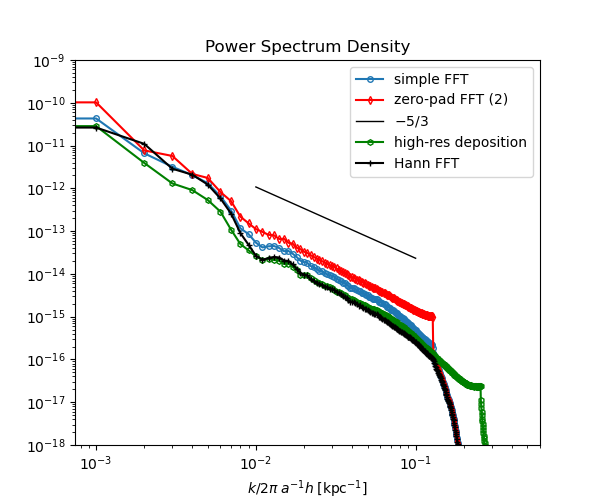

In [26]:
fig, ax = plt.subplots(figsize=(6,5))
t = np.logspace(np.log10(1e-2),np.log10(1e-1), 100)
ax.plot(k1d.astro/(2.0*np.pi), powerspectr, ls='-', marker='o', markerfacecolor='none', 
        markersize=4, label='simple FFT')
ax.plot(k1d_padded.astro/(2.0*np.pi), powerspectr_padded, ls='-', marker='d', 
        markerfacecolor='none', 
        color='r', markersize=4, label='zero-pad FFT (%d)'%(npads))
ax.plot(t, 5e-16*t**(-5./3.), ls='-', color='k',label=r'$-5/3$',lw=1.)
ax.plot(k1d_HR.astro/(2.0*np.pi), powerspectr_HR, ls='-', marker='h', markerfacecolor='none', 
        color='g', markersize=4, label='high-res deposition')
ax.plot(k1d.astro/(2.0*np.pi), powerspectr_hann, ls='-', marker='+', color='k',
        markerfacecolor='none', markersize=4, label='Hann FFT')
# ax.plot(k1d.astro/(2.0*np.pi), powerspectr_nonrel*1e8, ls='-', marker='^', color='orange',
        # markerfacecolor='none', markersize=4, label='simple FFT nonrel (x1e8)')
# ax.plot(k1d.astro/(2.0*np.pi), powerspectr_finufft, ls='-', marker='x', color='b',
#         markerfacecolor='none', markersize=4, label='finuFFT')

# ax.plot(k1d_uniform, powerspectr_ngp, ls='', marker='^', color='orange', markerfacecolor='none', markersize=4, label='np.fft ngp')
# ax.plot(k1d_uniform, powerspectr_cic, ls='', marker='x', color='g', markerfacecolor='none', markersize=4, label='np.fft cic')

# ax.set_xlabel('|k|')
ax.set_xlabel(k1d.astro.label('k / 2 \\pi'))
ax.set_xscale('log')
ax.set_yscale('log')

ax.legend()

ax.set_title(r'Power Spectrum Density')


# ax[0].set_ylim(ymin=-0.4, ymax=0.6)
ax.set_ylim(ymin=1e-18,ymax=1e-9)
# ax[1].set_xlim(xmax=30)

# plt.savefig('../images/turbulent_powerspectrum_%s.pdf'%(filter_type))
plt.show()


In [ ]:
# this is the total density 
density_cartesian = depo.deposit_variable('0_Density', weight='0_Volume')
hat_den = np.fft.rfftn(density_cartesian)
powerspectr_rho, k1d = power_spectrum1d_gpu(KX, KY, KZ, hat_den, 
                                                  (Nx,Ny,Nz), Lx)

In [ ]:
# this is the total density but with twice the 
# original resolution
density_cartesian_HR = depo_HR.deposit_variable('0_Density', weight='0_Volume')
hat_den_HR = np.fft.rfftn(density_cartesian_HR)
powerspectr_rho_HR, k1d_HR = power_spectrum1d_gpu(KX_HR, KY_HR, KZ_HR, hat_den_HR, 
                                                  (Nx_HR,Ny_HR,Nz_HR), Lx)

In [ ]:
# this is the delta rho (not divided by rho_0)
turb_density_cartesian = depo.deposit_variable(turbVar, weight='0_Volume')
hat_turb_den = np.fft.rfftn(turb_density_cartesian.value)
powerspectr_nonrel, k1d = power_spectrum1d_gpu(KX, KY, KZ, hat_turb_den, (Nx,Ny,Nz), Lx)

In [ ]:
# this is the delta rho but twice the resolution (not divided by rho_0)
turb_density_cartesian_HR = depo_HR.deposit_variable(turbVar, weight='0_Volume')
hat_turb_den_HR = np.fft.rfftn(turb_density_cartesian_HR.value)
powerspectr_nonrel_HR, k1d_HR = power_spectrum1d_gpu(KX_HR, KY_HR, KZ_HR, hat_turb_den_HR, 
                                                  (Nx_HR,Ny_HR,Nz_HR), Lx)

In [ ]:
# this is with finufft
# hat_density_finufft = finufft.nufft3d1(x, y, z, snap['0_Density'][sf.indicesFirstPass].astype('complex128'), 
#                                 n_modes=(Nx,Ny,Nz))

# this is to validate with grid points
# hat_density_finufft = finufft.nufft3d1(X.flatten(), Y.flatten(), Z.flatten(), 
#                                 density_cartesian.flatten().astype('complex128'), 
#                                 n_modes=(Nx,Ny,Nz))



# hat_density_finufft = np.fft.ifftshift(hat_density_finufft)


In [ ]:
# powerspectr_rho_finufft, k1d = power_spectrum1d_gpu(KKX, KKY, KKZ, hat_density_finufft/len(x), 
#                                                 (Nx,Ny,Nz), Lx, finufft=True, M=np.sqrt(len(x)))

In [ ]:
fig, ax = plt.subplots(figsize=(6,5))
t = np.logspace(np.log10(9e-3),np.log10(1e-1), 100)
ax.plot(k1d.astro/(2.0*np.pi), powerspectr_rho, ls='-', marker='o', markerfacecolor='none', 
        markersize=4, label='basic FFT')

ax.plot(k1d_HR.astro/(2.0*np.pi), powerspectr_rho_HR, ls='-', marker='h', 
        markerfacecolor='none', markersize=4, color='g',label='high-res deposition')

# ax.plot(k1d.astro/(2.0*np.pi), powerspectr_rho_finufft, ls='-', marker='s', 
#         markerfacecolor='none', markersize=4, color='r',label='finuFFT')

ax.plot(k1d.astro/(2.0*np.pi), powerspectr_nonrel, ls='-', marker='^', color='orange',
        markerfacecolor='none', markersize=4, label=r'$\delta \rho$')

ax.plot(k1d_HR.astro/(2.0*np.pi), powerspectr_nonrel_HR, ls='-', marker='^', 
        markerfacecolor='none', markersize=4, color='r',label=r'$\delta \rho$ (HR)')


ax.plot(t, 1e-15*t**(-5./3.), ls='-', color='k',label=r'$-5/3$',lw=1.)
# ax.plot(k1d_padded, powerspectr_padded, ls='-', marker='d', markerfacecolor='none', 
        # color='r', markersize=4, label='zero-pad FFT (3)')
# ax.plot(k1d, powerspectr_nonrel*1e9, ls='-', marker='^', color='orange',markerfacecolor='none', 
        # markersize=4, label='simple FFT nonrel (x1e9)')

# ax.plot(k1d_uniform, powerspectr_ngp, ls='', marker='^', color='orange', markerfacecolor='none', markersize=4, label='np.fft ngp')
# ax.plot(k1d_uniform, powerspectr_cic, ls='', marker='x', color='g', markerfacecolor='none', markersize=4, label='np.fft cic')

# ax.set_xlabel('|k|')
ax.set_xlabel(k1d.astro.label('k / 2 \\pi'))
ax.set_xscale('log')
ax.set_yscale('log')

ax.legend()

ax.set_title(r'Power Spectrum Total Density')


ax.set_ylim(ymin=1e-25)
# ax.set_ylim(ymin=1e-10)
# ax[1].set_xlim(xmax=30)


plt.show()


In [ ]:
# depo_TSC = tc.DepositCartesianGrid(snap, center, widths, npoints=nGrid, threadsperblock=256, 
#                                regionType='cartesian', kernel_type="TSC")

# depo_HR_TSC = tc.DepositCartesianGrid(snap, center, widths, npoints=2*nGrid, threadsperblock=256, 
#                                regionType='cartesian', kernel_type="TSC")

In [ ]:
# # this is the total density 
# density_cartesian_TSC = depo_TSC.deposit_variable('0_Density', weight='0_Volume')
# hat_den_TSC = np.fft.rfftn(density_cartesian_TSC)
# powerspectr_rho_TSC, k1d = power_spectrum1d_gpu(KX, KY, KZ, hat_den_TSC, 
#                                                   (Nx,Ny,Nz), Lx)



In [ ]:
# # this is the total density but with twice the 
# # original resolution
# density_cartesian_HR_TSC = depo_HR_TSC.deposit_variable('0_Density', weight='0_Volume')
# hat_den_HR_TSC = np.fft.rfftn(density_cartesian_HR_TSC)
# powerspectr_rho_HR_TSC, k1d_HR = power_spectrum1d_gpu(KX_HR, KY_HR, KZ_HR, hat_den_HR_TSC, 
#                                                   (Nx_HR,Ny_HR,Nz_HR), Lx)

In [ ]:
# fig, ax = plt.subplots(figsize=(6,5))
# t = np.logspace(np.log10(9e-3),np.log10(1e-1), 100)

# ax.plot(k1d.astro/(2.0*np.pi), powerspectr_rho, ls='-', color='g', label='basic FFT', alpha=0.5)

# ax.plot(k1d_HR.astro/(2.0*np.pi), powerspectr_rho_HR, ls='-', markersize=4, color='g',label='high-res deposition')


# ax.plot(k1d.astro/(2.0*np.pi), powerspectr_rho_TSC, ls='--', color='b', label='basic FFT TSC', alpha=0.5)

# ax.plot(k1d_HR.astro/(2.0*np.pi), powerspectr_rho_HR_TSC, ls='--',  markersize=4, color='b',label='high-res deposition TSC')

# # ax.plot(k1d.astro/(2.0*np.pi), powerspectr_rho_finufft, ls='-', marker='s', 
# #         markerfacecolor='none', markersize=4, color='r',label='finuFFT')


# ax.plot(t, 1e-15*t**(-5./3.), ls='-', color='k',label=r'$-5/3$',lw=1.)
# # ax.plot(k1d_padded, powerspectr_padded, ls='-', marker='d', markerfacecolor='none', 
#         # color='r', markersize=4, label='zero-pad FFT (3)')
# # ax.plot(k1d, powerspectr_nonrel*1e9, ls='-', marker='^', color='orange',markerfacecolor='none', 
#         # markersize=4, label='simple FFT nonrel (x1e9)')

# # ax.plot(k1d_uniform, powerspectr_ngp, ls='', marker='^', color='orange', markerfacecolor='none', markersize=4, label='np.fft ngp')
# # ax.plot(k1d_uniform, powerspectr_cic, ls='', marker='x', color='g', markerfacecolor='none', markersize=4, label='np.fft cic')

# # ax.set_xlabel('|k|')
# ax.set_xlabel(k1d.astro.label('k / 2 \\pi'))
# ax.set_xscale('log')
# ax.set_yscale('log')

# ax.legend()

# ax.set_title(r'Power Spectrum Total Density')


# ax.set_ylim(ymin=1e-25)
# # ax.set_ylim(ymin=1e-10)
# # ax[1].set_xlim(xmax=30)


# plt.show()


In [ ]:
# n1d = 256 

# x_uniform = 2.0*np.pi*np.linspace(0,1,n1d)
# y_uniform = 2.0*np.pi*np.linspace(0,1,n1d)
# z_uniform = 2.0*np.pi*np.linspace(0,1,n1d)

# X_uniform, Y_uniform, Z_uniform = np.meshgrid(x_uniform, y_uniform, z_uniform, indexing='ij')

# c_eval = np.zeros((n1d,n1d,n1d), dtype='float128')
# coeff = []
# for i in range(1,10):
#     rnd_amplitude = 0.1
#     rnd_phase     = np.random.uniform(size=1)*2.0*np.pi
#     rnd_phase = 0.0
#     c_eval +=  rnd_amplitude*(1/(1 + (i-4)**2))*np.exp(1j*Z_uniform*i + rnd_phase).real  \
#         + rnd_amplitude*(1/(1 + (i-4)**2))*np.exp(-1j*Z_uniform*i + rnd_phase).real
#     coeff.append(rnd_amplitude*(1/(1 + (i-4)**2)))

# vhat_eval = np.fft.rfftn(c_eval)

# kx_uniform = np.fft.fftfreq(n1d, d=1.0/n1d)
# ky_uniform = np.fft.fftfreq(n1d, d=1.0/n1d)
# kz_uniform = np.fft.rfftfreq(n1d, d=1.0/n1d)

# KX_uniform, KY_uniform, KZ_uniform = np.meshgrid(kx_uniform, ky_uniform, kz_uniform, indexing='ij')

# # powerspectr_eval, k1d_uniform = power_spectrum_numpyfft1d(KX_uniform, KY_uniform, KZ_uniform, 
# #                                                           vhat_eval, (n1d,n1d,n1d), 1.0)

# powerspectr_eval_gpu, k1d_uniform = power_spectrum1d_gpu(KX_uniform, KY_uniform, KZ_uniform, 
#                                                           vhat_eval, (n1d,n1d,n1d), 1.0)

In [ ]:
# npads = 3
# vhat_eval_pad = np.fft.rfftn(c_eval, s=(npads*n1d,npads*n1d,npads*n1d)) 
# # /np.sqrt(npads**3)
# kx_uniform_pad = np.fft.fftfreq(npads*n1d, d=1.0/n1d)
# ky_uniform_pad = np.fft.fftfreq(npads*n1d, d=1.0/n1d)
# kz_uniform_pad = np.fft.rfftfreq(npads*n1d, d=1.0/n1d)

# KX_uniform_pad, KY_uniform_pad, KZ_uniform_pad = np.meshgrid(kx_uniform_pad, 
#                                                              ky_uniform_pad, kz_uniform_pad, 
#                                                              indexing='ij')

# powerspectr_eval_gpu_pad, k1d_uniform_pad = power_spectrum1d_gpu(KX_uniform_pad, KY_uniform_pad, 
#                                                                  KZ_uniform_pad, 
#                                                                  vhat_eval_pad/np.sqrt(npads**3), 
#                                                                  (n1d,n1d,n1d), 1.0)

In [ ]:
# fig, ax = plt.subplots(figsize=(8,6))

# # ax.plot(k1d_uniform/(2.0*np.pi), powerspectr_eval, ls='', marker='+', color='r', markerfacecolor='none', markersize=4, label='np.fft eval')
# ax.plot(k1d_uniform/(2.0*np.pi), powerspectr_eval_gpu, ls='', marker='o', color='b', markerfacecolor='none', markersize=4, label='gpu')
# ax.plot(k1d_uniform_pad/(2.0*np.pi), powerspectr_eval_gpu_pad, ls='', marker='^', 
#         color='r', markerfacecolor='none', markersize=4, label='gpu')

# ax.plot(np.arange(1,10), 2.0*np.array(coeff)**2, ls='', marker='s', color='k', markerfacecolor='none', label='analytical')

# ax.set_xlabel('|k|')
# ax.set_yscale('log')

# ax.legend()

# ax.set_title(r'$y = 0 + \sum_{n \geq 1}^{10} a_n \cos (n x) $')


# ax.set_ylim(ymin=1e-8, ymax=1e0)
# ax.set_xlim(xmax=30)

# plt.show()